In [ ]:
import pandas as pd

In [8]:
df = pd.read_csv('student-mat.csv',sep=';')
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


In [15]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [20]:
df = df[['studytime','absences','G1','G2','G3']].copy()

In [21]:
df["pass"] = df["G3"].apply(lambda x: 1 if x>=10 else 0)

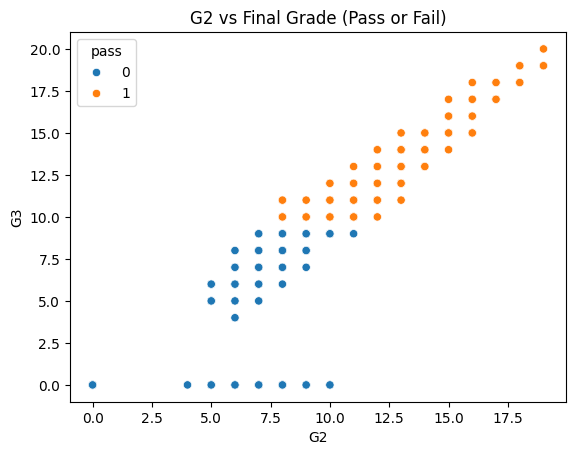

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='G2',y='G3',hue='pass',data = df)
plt.title('G2 vs Final Grade (Pass or Fail)')
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
X = df[['studytime','absences','G1','G2']]
Y = df['pass']
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2)

In [25]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,Y_train)

LogisticRegression()

In [26]:
y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score,confusion_matrix

print("Accuracy: ",accuracy_score(Y_test,y_pred))
print("Precision: ",confusion_matrix(Y_test,y_pred))

Accuracy:  0.8607594936708861
Precision:  [[16  2]
 [ 9 52]]


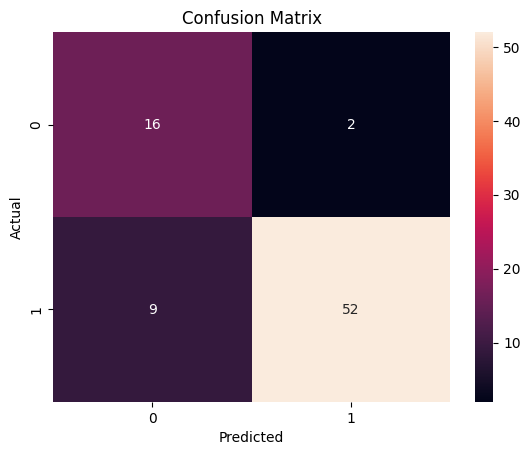

In [31]:
sns.heatmap(confusion_matrix(Y_test,y_pred),annot=True,fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()